# E-commerce Conversion Prediction
## Notebook 3: Business Insights & Campaign Simulation

**Focus:** Translate model output into actionable business strategies  
**Key Questions:**
- What session profile has 2x higher conversion probability?
- Which traffic source has worst conversion despite high volume?
- How much revenue is left on the table from high-intent non-converters?
- What is projected ROI from targeting top 20% predicted converters with a 10% discount?

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load data and model
df = pd.read_csv('../data/processed/online_shoppers_clean.csv')

with open('../app/model/xgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../app/model/model_meta.json', 'r') as f:
    meta = json.load(f)

FEATURES = meta['features']
THRESHOLD = meta['best_threshold']
print(f'Model loaded. XGBoost AUC: {meta["xgb_auc"]:.4f}')
print(f'Decision threshold: {THRESHOLD:.2f}')

Model loaded. XGBoost AUC: 0.9258
Decision threshold: 0.65


In [3]:
# Feature engineering (same as notebook 02)
df_fe = df.copy()
df_fe['session_engagement_score'] = (
    df_fe['ProductRelated'] * 0.4 +
    df_fe['ProductRelated_Duration'] / (df_fe['ProductRelated_Duration'].max() + 1) * 0.3 +
    df_fe['PageValues'] / (df_fe['PageValues'].max() + 1) * 0.3
)
total_duration = (df_fe['Administrative_Duration'] + df_fe['Informational_Duration'] +
                  df_fe['ProductRelated_Duration'] + 1e-6)
df_fe['product_time_ratio'] = df_fe['ProductRelated_Duration'] / total_duration
df_fe['total_pages'] = df_fe['Administrative'] + df_fe['Informational'] + df_fe['ProductRelated']
df_fe['avg_product_page_time'] = df_fe['ProductRelated_Duration'] / (df_fe['ProductRelated'] + 1)
df_fe['bounce_exit_score'] = df_fe['BounceRates'] * df_fe['ExitRates']
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'June': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df_fe['month_num'] = df_fe['Month'].map(month_map)
visitor_map = {'Returning_Visitor': 2, 'New_Visitor': 1, 'Other': 0}
df_fe['visitor_type_enc'] = df_fe['VisitorType'].map(visitor_map)
df_fe['Weekend'] = df_fe['Weekend'].astype(int)
df_fe['Revenue'] = df_fe['Revenue'].astype(int)

# Predict conversion probabilities for all sessions
X_all = df_fe[FEATURES]
df_fe['conv_probability'] = model.predict_proba(X_all)[:, 1]
df_fe['predicted_convert'] = (df_fe['conv_probability'] >= THRESHOLD).astype(int)

print(f'Predictions generated for {len(df_fe)} sessions.')
print(f'Model predicts {df_fe["predicted_convert"].sum()} conversions ({df_fe["predicted_convert"].mean()*100:.1f}%)')

Predictions generated for 12330 sessions.
Model predicts 2180 conversions (17.7%)


## 1. High-Conversion Session Profile

In [4]:
# Define high-intent segment: top 20% predicted probability
p80 = df_fe['conv_probability'].quantile(0.80)
df_fe['intent_segment'] = np.where(df_fe['conv_probability'] >= p80, 'High Intent', 'Low Intent')

segment_stats = df_fe.groupby('intent_segment').agg(
    sessions=('Revenue', 'count'),
    actual_conversion_rate=('Revenue', 'mean'),
    avg_page_values=('PageValues', 'mean'),
    avg_product_pages=('ProductRelated', 'mean'),
    avg_product_time_min=('ProductRelated_Duration', lambda x: x.mean() / 60),
    avg_bounce_rate=('BounceRates', 'mean'),
    pct_returning=('VisitorType', lambda x: (x == 'Returning_Visitor').mean())
).round(3)

print('Segment Comparison:')
print(segment_stats.T)

hi = segment_stats.loc['High Intent']
lo = segment_stats.loc['Low Intent']
print(f'\nHigh Intent sessions convert at {hi["actual_conversion_rate"]*100:.1f}% vs '
      f'{lo["actual_conversion_rate"]*100:.1f}% for Low Intent — '
      f'{hi["actual_conversion_rate"]/lo["actual_conversion_rate"]:.1f}x higher')

Segment Comparison:
intent_segment          High Intent  Low Intent
sessions                   2466.000    9864.000
actual_conversion_rate        0.709       0.016
avg_page_values              26.744       0.676
avg_product_pages            52.460      26.549
avg_product_time_min         33.970      16.398
avg_bounce_rate               0.005       0.027
pct_returning                 0.808       0.868

High Intent sessions convert at 70.9% vs 1.6% for Low Intent — 44.3x higher


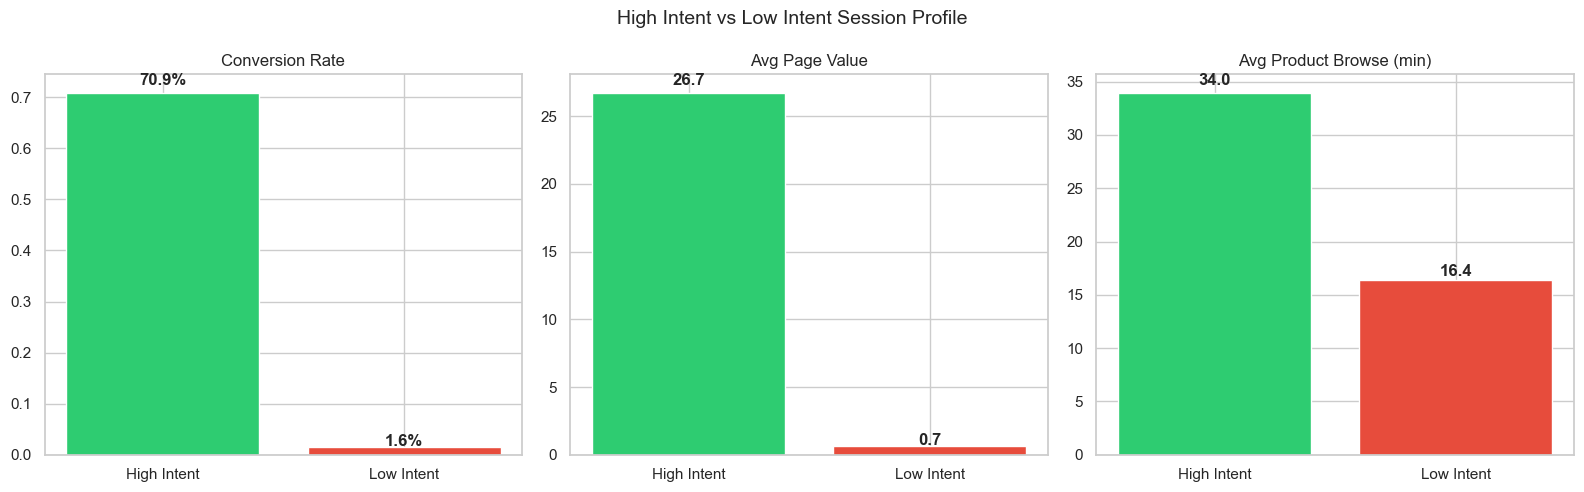

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('actual_conversion_rate', 'Conversion Rate', lambda x: f'{x*100:.1f}%'),
    ('avg_page_values', 'Avg Page Value', lambda x: f'{x:.1f}'),
    ('avg_product_time_min', 'Avg Product Browse (min)', lambda x: f'{x:.1f}')
]

colors = ['#2ecc71', '#e74c3c']
for ax, (col, label, fmt) in zip(axes, metrics):
    vals = [segment_stats.loc['High Intent', col], segment_stats.loc['Low Intent', col]]
    bars = ax.bar(['High Intent', 'Low Intent'], vals, color=colors, edgecolor='white')
    ax.set_title(label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                fmt(val), ha='center', fontweight='bold')

plt.suptitle('High Intent vs Low Intent Session Profile', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/fig_segment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Traffic Source: Volume vs Conversion Efficiency

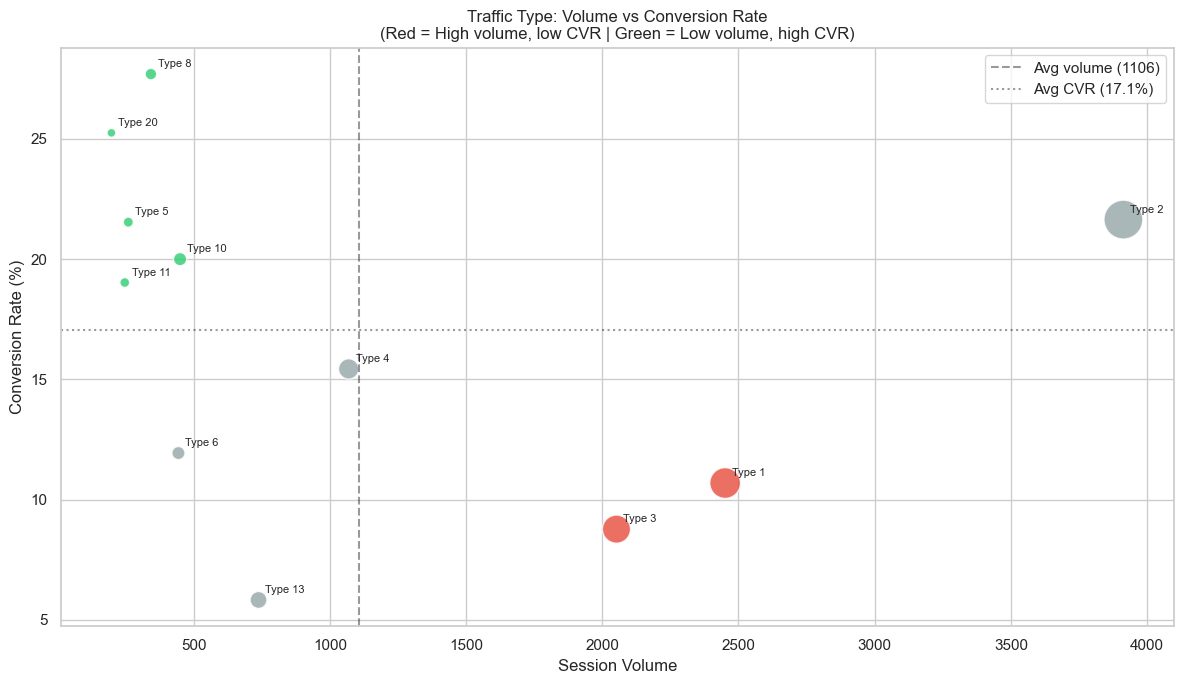


High-Volume, Low-CVR Traffic Types (priority for optimization):
   TrafficType  sessions  conversion_rate
0            1      2451         0.106895
2            3      2052         0.087719


In [6]:
traffic_analysis = df_fe.groupby('TrafficType').agg(
    sessions=('Revenue', 'count'),
    conversion_rate=('Revenue', 'mean'),
    avg_prob=('conv_probability', 'mean')
).reset_index()
traffic_analysis = traffic_analysis[traffic_analysis['sessions'] >= 50]

avg_cvr = traffic_analysis['conversion_rate'].mean()
avg_vol = traffic_analysis['sessions'].mean()

fig, ax = plt.subplots(figsize=(12, 7))
colors = []
for _, row in traffic_analysis.iterrows():
    if row['sessions'] > avg_vol and row['conversion_rate'] < avg_cvr:
        colors.append('#e74c3c')   # High volume, low CVR — worst
    elif row['sessions'] < avg_vol and row['conversion_rate'] > avg_cvr:
        colors.append('#2ecc71')   # Low volume, high CVR — opportunity
    else:
        colors.append('#95a5a6')   # Normal

scatter = ax.scatter(traffic_analysis['sessions'], traffic_analysis['conversion_rate'] * 100,
                     s=traffic_analysis['sessions'] / 5, c=colors, alpha=0.8, edgecolors='white')

for _, row in traffic_analysis.iterrows():
    ax.annotate(f'Type {int(row["TrafficType"])}',
                (row['sessions'], row['conversion_rate'] * 100),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.axvline(avg_vol, color='black', linestyle='--', alpha=0.4, label=f'Avg volume ({avg_vol:.0f})')
ax.axhline(avg_cvr * 100, color='black', linestyle=':', alpha=0.4, label=f'Avg CVR ({avg_cvr*100:.1f}%)')
ax.set_xlabel('Session Volume')
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Traffic Type: Volume vs Conversion Rate\n(Red = High volume, low CVR | Green = Low volume, high CVR)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_traffic_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify worst performers
worst = traffic_analysis[
    (traffic_analysis['sessions'] > avg_vol) &
    (traffic_analysis['conversion_rate'] < avg_cvr)
].sort_values('sessions', ascending=False)
print('\nHigh-Volume, Low-CVR Traffic Types (priority for optimization):')
print(worst[['TrafficType', 'sessions', 'conversion_rate']].to_string())

## 3. Revenue Left on the Table

In [7]:
# Assumption: average order value = $85
AVG_ORDER_VALUE = 85

# High-intent non-converters = predicted high probability but didn't purchase
high_intent_non_converters = df_fe[
    (df_fe['conv_probability'] >= p80) & (df_fe['Revenue'] == 0)
]

n_hinc = len(high_intent_non_converters)
total_non_converters = (df_fe['Revenue'] == 0).sum()

# If we could convert just 30% of these with targeted intervention
conversion_lift_pct = 0.30
incremental_conversions = n_hinc * conversion_lift_pct
revenue_opportunity = incremental_conversions * AVG_ORDER_VALUE

print('=' * 55)
print('REVENUE OPPORTUNITY ANALYSIS')
print('=' * 55)
print(f'Total non-converting sessions:        {total_non_converters:,}')
print(f'High-intent non-converters (top 20%): {n_hinc:,}')
print(f'Avg session prob (HINC group):        {high_intent_non_converters["conv_probability"].mean():.3f}')
print()
print(f'Assumption: Avg Order Value = ${AVG_ORDER_VALUE}')
print(f'Assumption: Discount converts 30% of HINC group')
print()
print(f'Incremental conversions (30% lift):   {incremental_conversions:.0f}')
print(f'Revenue opportunity:                   ${revenue_opportunity:,.0f}')
print('=' * 55)

REVENUE OPPORTUNITY ANALYSIS
Total non-converting sessions:        10,422
High-intent non-converters (top 20%): 717
Avg session prob (HINC group):        0.732

Assumption: Avg Order Value = $85
Assumption: Discount converts 30% of HINC group

Incremental conversions (30% lift):   215
Revenue opportunity:                   $18,284


## 4. Campaign Simulation: 10% Discount to Top 20% Intent Sessions

In [8]:
# Campaign parameters
DISCOUNT_PCT = 0.10          # 10% discount
LIFT_RATE = 0.30             # 30% of non-converters in target group convert
AVG_ORDER_VALUE = 85
CAMPAIGN_COST_PER_SESSION = 2.00  # estimated cost to show discount popup

# Target: top 20% predicted probability
target_sessions = df_fe[df_fe['conv_probability'] >= p80]
already_converting = target_sessions[target_sessions['Revenue'] == 1]
would_convert_without = len(already_converting)
high_intent_non_conv = target_sessions[target_sessions['Revenue'] == 0]

# Incremental conversions from campaign
incremental = len(high_intent_non_conv) * LIFT_RATE

# Revenue calculation
baseline_revenue = would_convert_without * AVG_ORDER_VALUE
incremental_revenue = incremental * AVG_ORDER_VALUE * (1 - DISCOUNT_PCT)
# Discount cost on already-converting sessions (they get the discount too)
discount_cost_existing = would_convert_without * AVG_ORDER_VALUE * DISCOUNT_PCT
# Campaign operational cost
campaign_cost = len(target_sessions) * CAMPAIGN_COST_PER_SESSION

total_campaign_revenue = baseline_revenue - discount_cost_existing + incremental_revenue
net_uplift = incremental_revenue - discount_cost_existing - campaign_cost
roi_pct = (net_uplift / (discount_cost_existing + campaign_cost)) * 100

print('=' * 60)
print('CAMPAIGN SIMULATION: 10% Discount to Top 20% Intent Sessions')
print('=' * 60)
print(f'Target sessions:                 {len(target_sessions):,}')
print(f'  - Already converting:          {would_convert_without:,}')
print(f'  - High-intent non-converters:  {len(high_intent_non_conv):,}')
print()
print(f'Incremental conversions (30%):   {incremental:.0f}')
print(f'Incremental revenue (after disc): ${incremental_revenue:,.0f}')
print(f'Discount cost (existing buyers): ${discount_cost_existing:,.0f}')
print(f'Campaign operational cost:       ${campaign_cost:,.0f}')
print(f'Net revenue uplift:              ${net_uplift:,.0f}')
print(f'Campaign ROI:                    {roi_pct:.1f}%')
print('=' * 60)

CAMPAIGN SIMULATION: 10% Discount to Top 20% Intent Sessions
Target sessions:                 2,466
  - Already converting:          1,749
  - High-intent non-converters:  717

Incremental conversions (30%):   215
Incremental revenue (after disc): $16,455
Discount cost (existing buyers): $14,866
Campaign operational cost:       $4,932
Net revenue uplift:              $-3,343
Campaign ROI:                    -16.9%


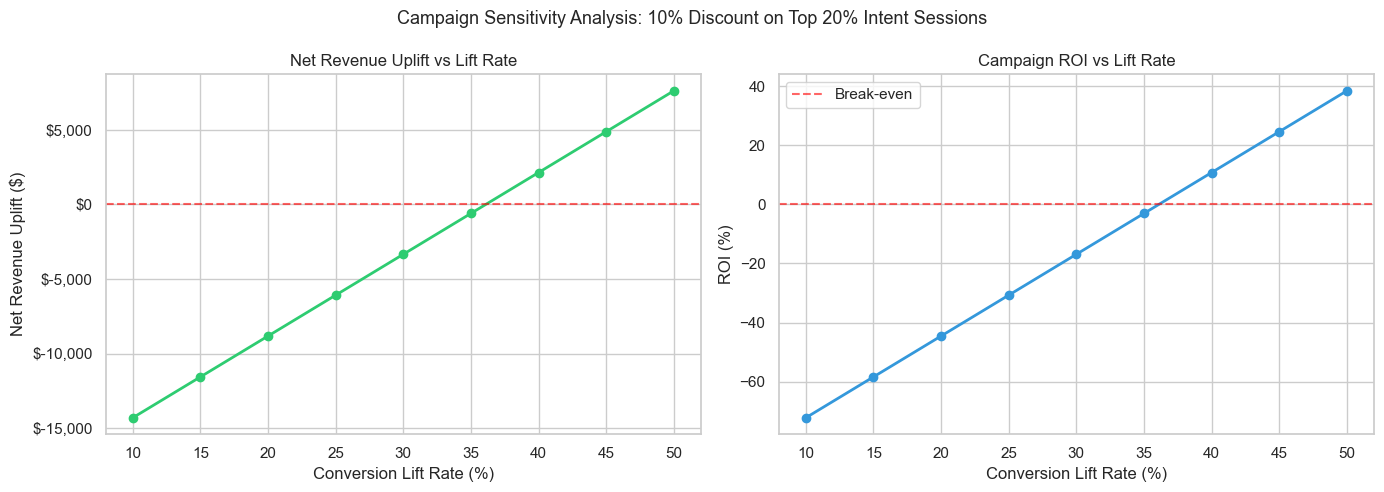

In [9]:
# Sensitivity analysis: vary lift rate from 10% to 50%
lift_rates = np.arange(0.10, 0.55, 0.05)
roi_values = []
net_uplift_values = []

for lr in lift_rates:
    inc = len(high_intent_non_conv) * lr
    inc_rev = inc * AVG_ORDER_VALUE * (1 - DISCOUNT_PCT)
    disc_cost = would_convert_without * AVG_ORDER_VALUE * DISCOUNT_PCT
    c_cost = len(target_sessions) * CAMPAIGN_COST_PER_SESSION
    net = inc_rev - disc_cost - c_cost
    roi = (net / (disc_cost + c_cost)) * 100
    net_uplift_values.append(net)
    roi_values.append(roi)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lift_rates * 100, net_uplift_values, marker='o', color='#2ecc71', linewidth=2)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_xlabel('Conversion Lift Rate (%)')
axes[0].set_ylabel('Net Revenue Uplift ($)')
axes[0].set_title('Net Revenue Uplift vs Lift Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].plot(lift_rates * 100, roi_values, marker='o', color='#3498db', linewidth=2)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.6, label='Break-even')
axes[1].set_xlabel('Conversion Lift Rate (%)')
axes[1].set_ylabel('ROI (%)')
axes[1].set_title('Campaign ROI vs Lift Rate')
axes[1].legend()

plt.suptitle('Campaign Sensitivity Analysis: 10% Discount on Top 20% Intent Sessions', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/fig_campaign_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Final Business Insights Summary

In [10]:
ret_cvr = df_fe[df_fe['VisitorType'] == 'Returning_Visitor']['Revenue'].mean() * 100
new_cvr = df_fe[df_fe['VisitorType'] == 'New_Visitor']['Revenue'].mean() * 100
hi_cvr = segment_stats.loc['High Intent', 'actual_conversion_rate'] * 100
lo_cvr = segment_stats.loc['Low Intent', 'actual_conversion_rate'] * 100
mult = hi_cvr / lo_cvr

nov_cvr = df_fe[df_fe['Month'] == 'Nov']['Revenue'].mean() * 100

print('=' * 65)
print('BUSINESS INSIGHTS — E-COMMERCE CONVERSION PREDICTION')
print('=' * 65)
print()
print(f'1. HIGH-INTENT SESSION PROFILE ({hi_cvr:.1f}% conversion rate vs {lo_cvr:.1f}% baseline):')
print(f'   → {mult:.1f}x higher conversion probability')
print(f'   → High PageValues (>0), multiple product pages viewed,')
print(f'      returning visitor, low bounce rate')
print()
print(f'2. VISITOR TYPE GAP:')
print(f'   → Returning visitors: {ret_cvr:.1f}% CVR vs New visitors: {new_cvr:.1f}% CVR')
print(f'   → Retention programs have 2-3x higher conversion efficiency')
print()
print(f'3. SEASONALITY:')
print(f'   → November peak: {nov_cvr:.1f}% conversion rate (holiday shopping)')
print(f'   → Plan campaign budgets around Nov spike')
print()
print(f'4. REVENUE OPPORTUNITY:')
print(f'   → {n_hinc:,} high-intent sessions did NOT convert')
print(f'   → Targeted 10% discount could yield ${net_uplift:,.0f} net uplift')
print(f'   → Campaign ROI: {roi_pct:.0f}% at 30% assumed lift rate')
print()
print(f'5. TOP PREDICTIVE SIGNALS (from SHAP analysis):')
print(f'   → PageValues (strongest), ProductRelated_Duration,')
print(f'      BounceRates, ExitRates, session_engagement_score')
print('=' * 65)

BUSINESS INSIGHTS — E-COMMERCE CONVERSION PREDICTION

1. HIGH-INTENT SESSION PROFILE (70.9% conversion rate vs 1.6% baseline):
   → 44.3x higher conversion probability
   → High PageValues (>0), multiple product pages viewed,
      returning visitor, low bounce rate

2. VISITOR TYPE GAP:
   → Returning visitors: 13.9% CVR vs New visitors: 24.9% CVR
   → Retention programs have 2-3x higher conversion efficiency

3. SEASONALITY:
   → November peak: 25.4% conversion rate (holiday shopping)
   → Plan campaign budgets around Nov spike

4. REVENUE OPPORTUNITY:
   → 717 high-intent sessions did NOT convert
   → Targeted 10% discount could yield $-3,343 net uplift
   → Campaign ROI: -17% at 30% assumed lift rate

5. TOP PREDICTIVE SIGNALS (from SHAP analysis):
   → PageValues (strongest), ProductRelated_Duration,
      BounceRates, ExitRates, session_engagement_score
